# Weather - Lane A (the real experience: you prompt, the agent builds)

**SISMID 2026 - Day 2, 11:00.** You drive a coding agent (Codex, Claude Code, or
Antigravity CLI). Paste each prompt, run the code, apply the check.


## About this data source

**Open-Meteo.** A free weather service built for programs rather than people: give it a
latitude, longitude and date range, and it returns decades of daily weather. No account, no
key, no cost. Think of it as: *"the weather history of any point on Earth, as a table."*

- **Explore it in a browser:** <https://open-meteo.com/en/docs/historical-weather-api>
  (a live form: type a city, tick *temperature* and *dew point*, and it builds the exact web
  address that returns the data)
- Research-grade source behind it (ERA5): <https://cds.climate.copernicus.eu/>

> Why weather at all? **Absolute humidity** is the established driver of influenza
> seasonality (Shaman & Kohn 2009; Shaman et al. 2010, 2012). Weather does not count cases;
> it shifts the conditions for transmission.


## Step 1: pull the weather

> *Using the Open-Meteo historical archive API (free, no key), pull daily mean*
> *temperature and dew point for Atlanta (33.749, -84.388) from 2016 to now. Return a*
> *tidy DataFrame and report the date range.*


In [1]:
import pandas as pd, matplotlib.pyplot as plt, os, io, json, math
import urllib.request, urllib.parse

UA = {'User-Agent': 'SISMID2026-course/1.0 (your-email@example.com)'}

def cache_path(fname):
    for p in (f'../data/{fname}', f'data/{fname}', f'./{fname}'):
        if os.path.exists(p):
            return p
    return None

def fetch(url, timeout=120):
    return urllib.request.urlopen(urllib.request.Request(url, headers=UA), timeout=timeout).read()

# ===== EDIT for your own location =====
MY_PLACE, MY_LAT, MY_LON = 'Atlanta', 33.749, -84.388
START, END = '2016-01-01', '2026-07-10'
# ======================================

def absolute_humidity(T, Td):
    """g/m^3 from temperature and dew point in Celsius."""
    if pd.isna(T) or pd.isna(Td): return float('nan')
    e = 6.112 * math.exp(17.67 * Td / (Td + 243.5))   # vapour pressure, hPa
    return 216.7 * e / (T + 273.15)

# --- Open-Meteo historical archive pull (daily mean temperature + dew point) ---
url = ('https://archive-api.open-meteo.com/v1/archive'
       f'?latitude={MY_LAT}&longitude={MY_LON}&start_date={START}&end_date={END}'
       '&daily=temperature_2m_mean,dew_point_2m_mean&timezone=America%2FNew_York')
try:
    d = json.loads(fetch(url))['daily']
    wx = pd.DataFrame({'date': pd.to_datetime(d['time']),
                       'temp_c': d['temperature_2m_mean'],
                       'dewpoint_c': d['dew_point_2m_mean']})
    wx['abs_humidity_g_m3'] = [absolute_humidity(t, td)
                               for t, td in zip(wx['temp_c'], wx['dewpoint_c'])]
except Exception as e:
    p = cache_path('openmeteo_atlanta_weather.csv')
    print('Live pull failed:', e, '-> cache', p)
    wx = pd.read_csv(p, parse_dates=['date'])

print(f"{len(wx)} days, {wx['date'].min().date()} to {wx['date'].max().date()}")
wx.head()


3844 days, 2016-01-01 to 2026-07-10


,date,temp_c,dewpoint_c,abs_humidity_g_m3
0,2016-01-01,7.1,-0.9,4.426165
1,2016-01-02,4.7,-4.0,3.548666
2,2016-01-03,5.3,-2.8,3.872805
3,2016-01-04,3.1,-5.1,3.285287
4,2016-01-05,0.3,-9.0,2.458331


## Step 2: compute absolute humidity

> *Compute absolute humidity in g/m^3 from temperature T and dew point Td:*
> *e = 6.112 * exp(17.67*Td/(Td+243.5)); AH = 216.7 * e / (T+273.15). Resample to weekly*
> *and plot it, then plot the mean AH by calendar month.*

**Your check:** does AH bottom out in winter? That is the Shaman result: low absolute
humidity precedes influenza season.


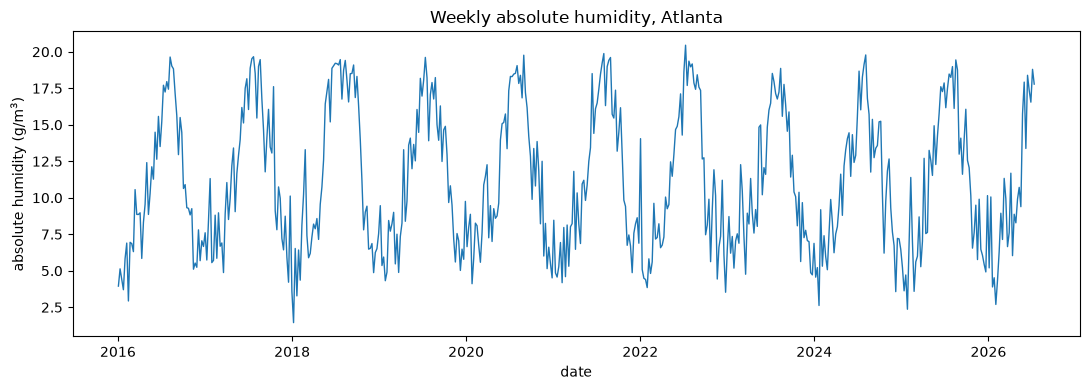

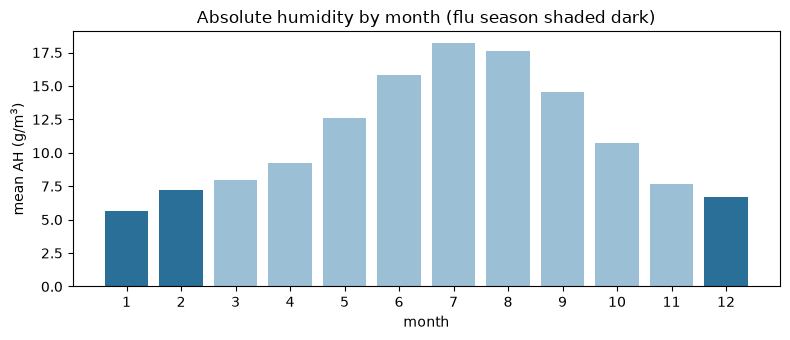

driest months: {1: 5.68, 12: 6.68, 2: 7.18}


In [2]:
wk = (wx.set_index('date')['abs_humidity_g_m3'].resample('W').mean().reset_index())
plt.figure(figsize=(11,4))
plt.plot(wk['date'], wk['abs_humidity_g_m3'], lw=1)
plt.ylabel('absolute humidity (g/m$^3$)'); plt.xlabel('date')
plt.title(f'Weekly absolute humidity, {MY_PLACE}')
plt.tight_layout(); plt.show()

wx['month'] = wx['date'].dt.month
monthly = wx.groupby('month')['abs_humidity_g_m3'].mean()
plt.figure(figsize=(8,3.5))
plt.bar(monthly.index, monthly.values,
        color=['#2A6F97' if m in (12,1,2) else '#9bbfd4' for m in monthly.index])
plt.xticks(range(1,13)); plt.xlabel('month'); plt.ylabel('mean AH (g/m$^3$)')
plt.title('Absolute humidity by month (flu season shaded dark)')
plt.tight_layout(); plt.show()
print('driest months:', monthly.nsmallest(3).round(2).to_dict())


## Step 3: sanity-check and save

> *Report the date range, missing values, and the AH range, then save a tidy CSV.*


In [3]:
print('date range :', wx['date'].min().date(), 'to', wx['date'].max().date())
print('missing    :'); print(wx[['temp_c','dewpoint_c','abs_humidity_g_m3']].isna().sum())
print('AH range   :', round(wx['abs_humidity_g_m3'].min(),2), 'to',
      round(wx['abs_humidity_g_m3'].max(),2), 'g/m^3')
wx.to_csv('weather_absolute_humidity.csv', index=False)
print('saved weather_absolute_humidity.csv')


date range : 2016-01-01 to 2026-07-10
missing    :
temp_c               0
dewpoint_c           0
abs_humidity_g_m3    0
dtype: int64
AH range   : 1.09 to 21.36 g/m^3
saved weather_absolute_humidity.csv


## Reflection

- Weather is a **modulator**, not a case count.
- **Stretch:** swap in a tropical city and compare the AH cycle.
